# CME Transit Time Prediction - Results Visualization

This notebook reads pre-computed results from `Results/0_results_100_best.csv` and
generates all publication-quality figures.

**No computation is needed**: simply run all cells in order.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Publication-style settings
sns.set_context("paper")
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.dpi": 150,
})

COLORS = {"train": "lightblue", "val": "lightgreen", "test": "pink"}
print("Libraries loaded.")

Libraries loaded.


## 1. Load results

In [2]:
# Adjust the path to the CSV file if needed
RESULTS_PATH = "Results/final_results.csv"

df = pd.read_csv(RESULTS_PATH)
print(f"Loaded {len(df)} realizations.")
print(f"Columns: {list(df.columns)}")

Loaded 47973 realizations.
Columns: ['mae_t_train_real', 'mae_t_train_aug', 'medae_t_train_real', 'medae_t_train_aug', 'mae_t_val_real', 'mae_t_val_aug', 'medae_t_val_real', 'medae_t_val_aug', 'mae_t_train_tot', 'mae_t_val_tot', 'mae_t_test_tot', 'medae_t_train_tot', 'medae_t_val_tot', 'medae_t_test_tot', 'abs_error_t_train_real', 'abs_error_t_val_real', 'abs_error_t_test_tot', 'abs_error_t_train_aug', 'abs_error_t_val_aug', 'rel_error_t_train_real', 'rel_error_t_val_real', 'rel_error_t_test_tot', 'rel_error_t_train_aug', 'rel_error_t_val_aug']


## 2. Extract metrics

In [3]:
# Per-realization scalar metrics
mae_train_real   = df["mae_t_train_real"].dropna().values
mae_val_real     = df["mae_t_val_real"].dropna().values
mae_test         = df["mae_t_test_tot"].dropna().values

medae_train_real = df["medae_t_train_real"].dropna().values
medae_val_real   = df["medae_t_val_real"].dropna().values
medae_test       = df["medae_t_test_tot"].dropna().values

mae_train_aug    = df["mae_t_train_aug"].dropna().values
mae_val_aug      = df["mae_t_val_aug"].dropna().values
medae_train_aug  = df["medae_t_train_aug"].dropna().values
medae_val_aug    = df["medae_t_val_aug"].dropna().values

# Per-event error arrays (one value per CME event across all realizations)
abs_err_train_real = df["abs_error_t_train_real"].dropna().values
abs_err_val_real   = df["abs_error_t_val_real"].dropna().values
abs_err_test       = df["abs_error_t_test_tot"].dropna().values
abs_err_train_aug  = df["abs_error_t_train_aug"].dropna().values
abs_err_val_aug    = df["abs_error_t_val_aug"].dropna().values

rel_err_train_real = df["rel_error_t_train_real"].dropna().values
rel_err_val_real   = df["rel_error_t_val_real"].dropna().values
rel_err_test       = df["rel_error_t_test_tot"].dropna().values
rel_err_train_aug  = df["rel_error_t_train_aug"].dropna().values
rel_err_val_aug    = df["rel_error_t_val_aug"].dropna().values

print("MAE (real events):")
print(f"  Train : {mae_train_real.mean():.2f} +/- {mae_train_real.std():.2f} h")
print(f"  Val   : {mae_val_real.mean():.2f} +/- {mae_val_real.std():.2f} h")
print(f"  Test  : {mae_test.mean():.2f} +/- {mae_test.std():.2f} h")

MAE (real events):
  Train : 7.13 +/- 2.15 h
  Val   : 11.23 +/- 5.55 h
  Test  : 13.34 +/- 3.94 h


## 3. Boxplots - MAE and MedAE (real events)

/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_43487/2859787939.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_flat, labels=labels, patch_artist=True, showmeans=False)


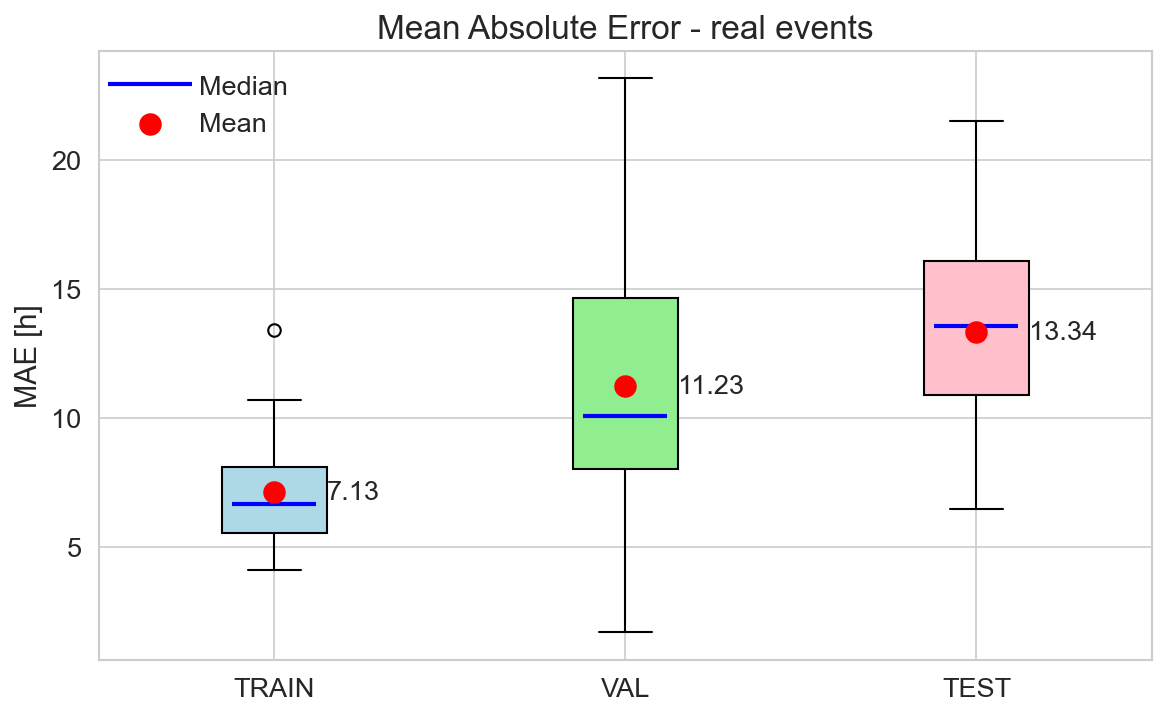

/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_43487/2859787939.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_flat, labels=labels, patch_artist=True, showmeans=False)


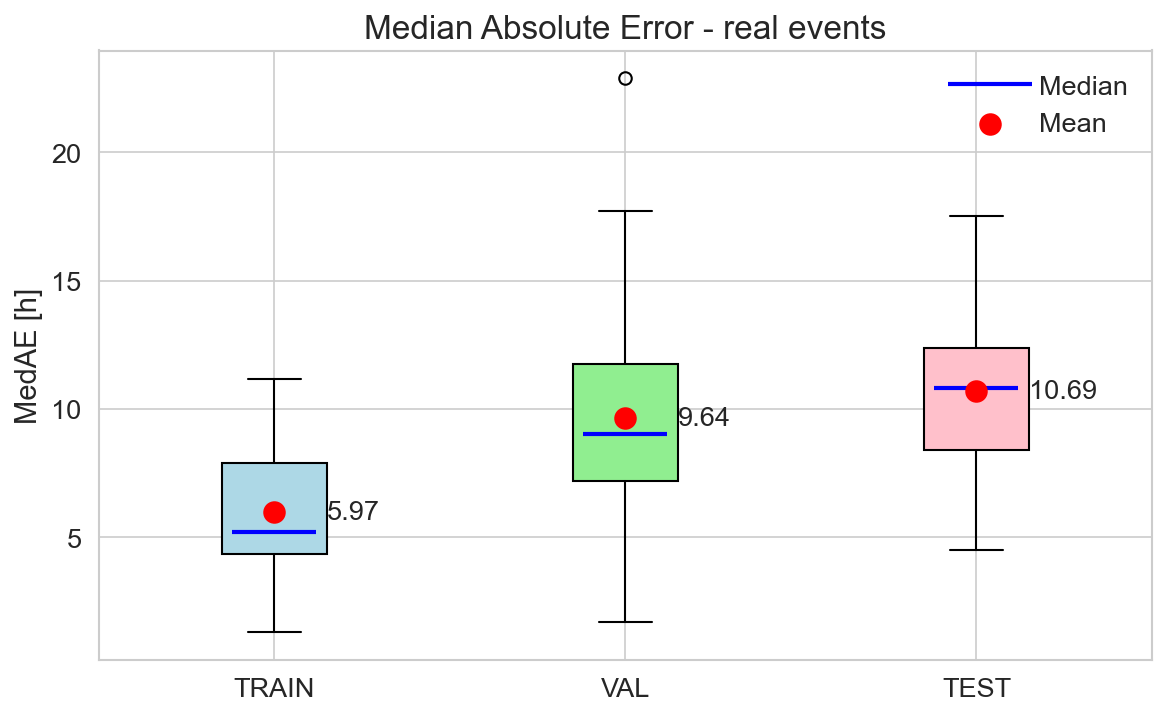

In [4]:
def create_boxplot(data_list, labels, y_label, title=""):
    """
    Boxplot with mean (red dot) and median (blue dash) annotated.
    
    Each element of data_list is one box (one train/val/test split).
    Mean and median values are printed next to each box.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    data_flat = [np.ravel(d) for d in data_list]

    bp = ax.boxplot(data_flat, labels=labels, patch_artist=True, showmeans=False)

    for patch, label in zip(bp["boxes"], labels):
        if "TRAIN" in label:
            patch.set_facecolor(COLORS["train"])
        elif "VAL" in label:
            patch.set_facecolor(COLORS["val"])
        else:
            patch.set_facecolor(COLORS["test"])

    for median in bp["medians"]:
        median.set_visible(False)

    means   = [np.mean(d)   for d in data_flat]
    medians = [np.median(d) for d in data_flat]
    xs = range(1, len(labels) + 1)

    ax.plot(xs, medians, marker="_", color="blue",
            markersize=40, mew=2, linestyle="None", zorder=5, label="Median")
    ax.scatter(xs, means, marker="o", color="red", s=100, zorder=5, label="Mean")

    for x, mean in zip(xs, means):
        ax.text(x + 0.15, mean, f"{mean:.2f}", va="center", ha="left", fontsize=13)

    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


create_boxplot(
    [mae_train_real, mae_val_real, mae_test],
    ["TRAIN", "VAL", "TEST"],
    y_label="MAE [h]",
    title="Mean Absolute Error - real events",
)

create_boxplot(
    [medae_train_real, medae_val_real, medae_test],
    ["TRAIN", "VAL", "TEST"],
    y_label="MedAE [h]",
    title="Median Absolute Error - real events",
)

## 4. Boxplots - Augmented events

/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_43487/2052223822.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_flat, labels=labels, patch_artist=True,


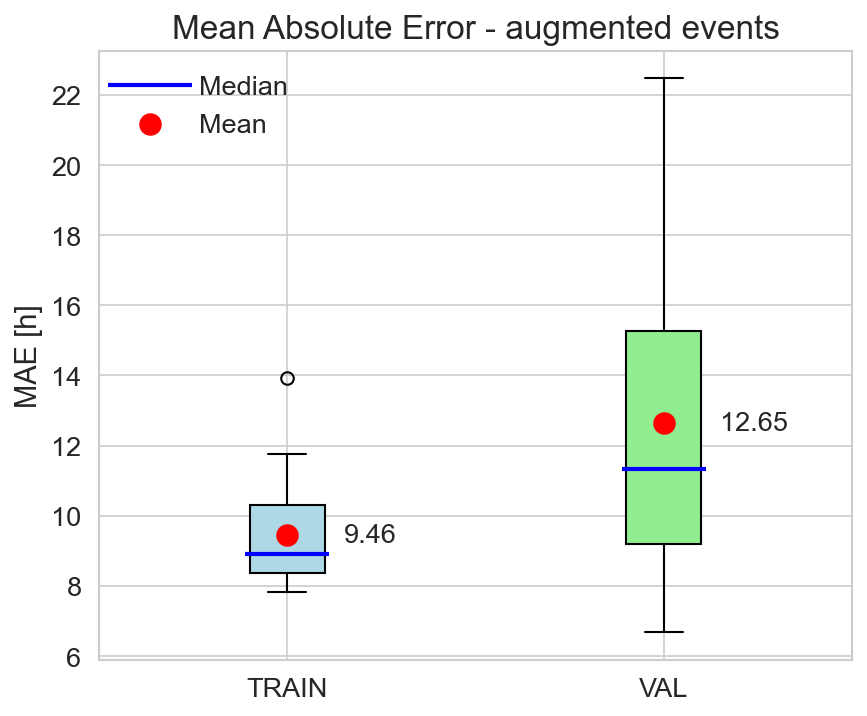

/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_43487/2052223822.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_flat, labels=labels, patch_artist=True,


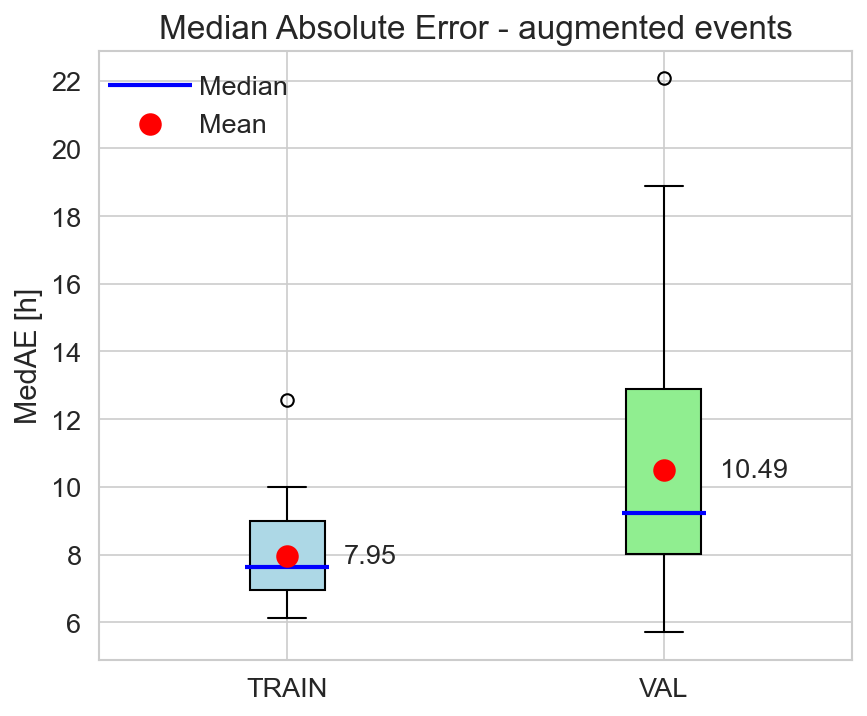

In [5]:
def create_boxplot_aug(data_list, labels, y_label, title=""):
    """Boxplot variant for 2-category comparisons (narrower boxes)."""
    fig, ax = plt.subplots(figsize=(6, 5))
    data_flat = [np.ravel(d) for d in data_list]

    bp = ax.boxplot(data_flat, labels=labels, patch_artist=True,
                    showmeans=False, widths=0.2)

    for patch, label in zip(bp["boxes"], labels):
        patch.set_facecolor(COLORS["train"] if "TRAIN" in label else COLORS["val"])

    for median in bp["medians"]:
        median.set_visible(False)

    means   = [np.mean(d)   for d in data_flat]
    medians = [np.median(d) for d in data_flat]
    xs = range(1, len(labels) + 1)

    ax.plot(xs, medians, marker="_", color="blue",
            markersize=40, mew=2, linestyle="None", zorder=5, label="Median")
    ax.scatter(xs, means, marker="o", color="red", s=100, zorder=5, label="Mean")

    for x, mean in zip(xs, means):
        ax.text(x + 0.15, mean, f"{mean:.2f}", va="center", ha="left", fontsize=13)

    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


create_boxplot_aug(
    [mae_train_aug, mae_val_aug],
    ["TRAIN", "VAL"],
    y_label="MAE [h]",
    title="Mean Absolute Error - augmented events",
)
create_boxplot_aug(
    [medae_train_aug, medae_val_aug],
    ["TRAIN", "VAL"],
    y_label="MedAE [h]",
    title="Median Absolute Error - augmented events",
)

## 5. Boxplots - Relative error

/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_43487/2859787939.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_flat, labels=labels, patch_artist=True, showmeans=False)


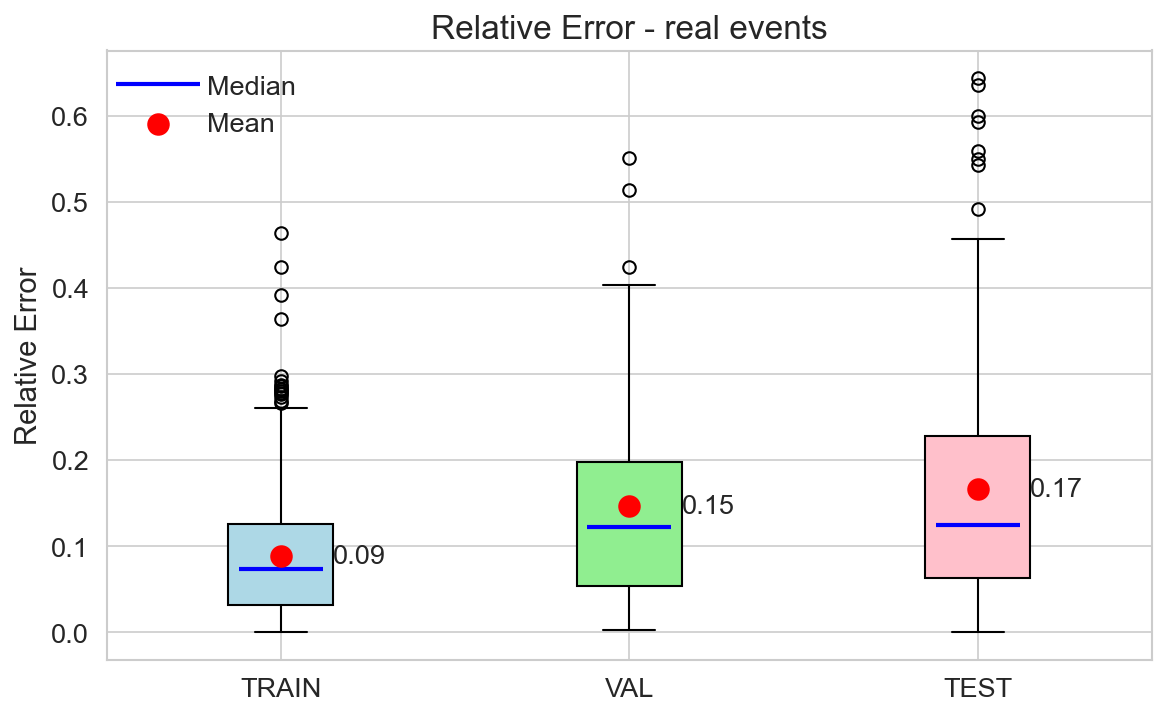

/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_43487/2052223822.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_flat, labels=labels, patch_artist=True,


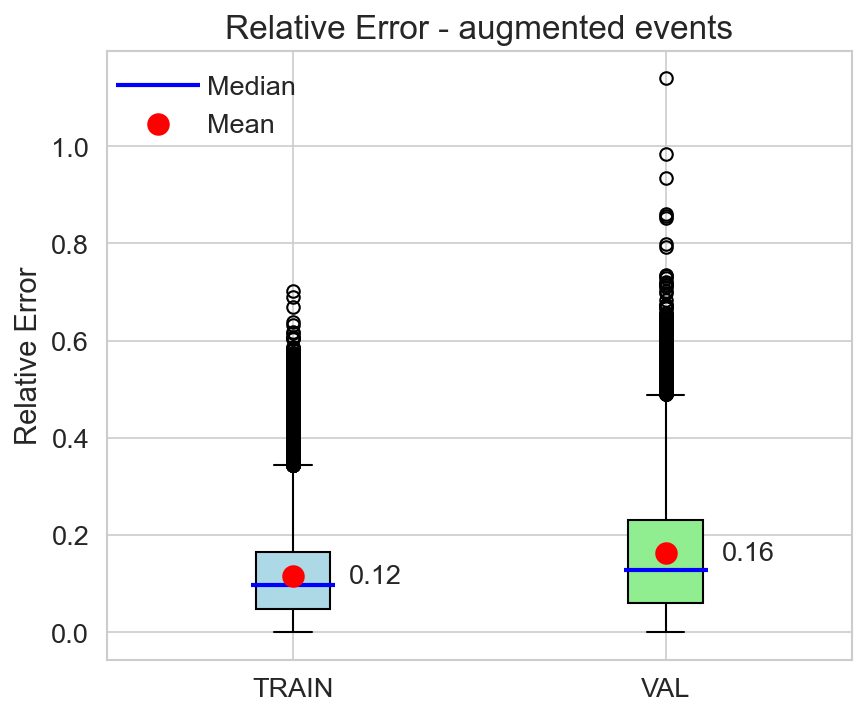

In [6]:
create_boxplot(
    [rel_err_train_real, rel_err_val_real, rel_err_test],
    ["TRAIN", "VAL", "TEST"],
    y_label="Relative Error",
    title="Relative Error - real events",
)

create_boxplot_aug(
    [rel_err_train_aug, rel_err_val_aug],
    ["TRAIN", "VAL"],
    y_label="Relative Error",
    title="Relative Error - augmented events",
)

## 6. Histograms - Absolute error distribution

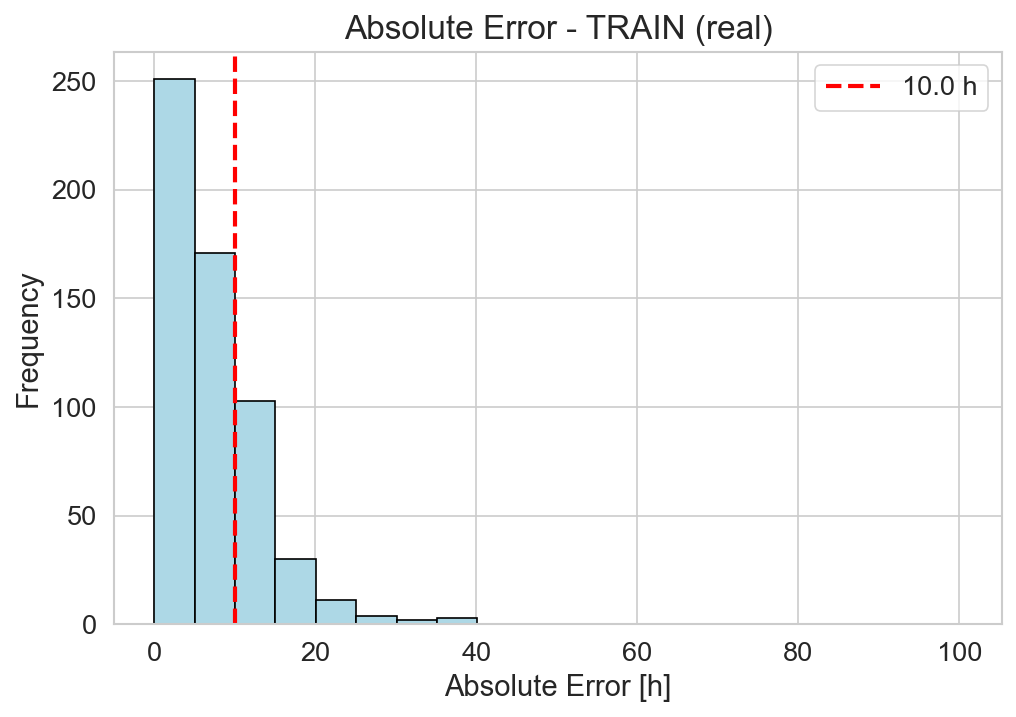

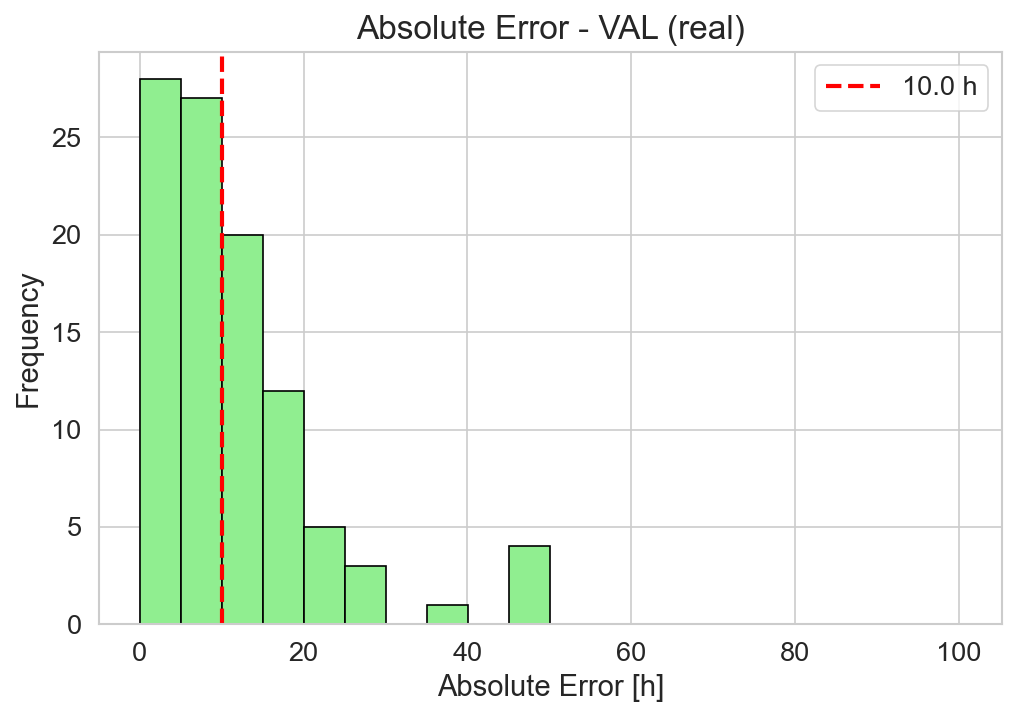

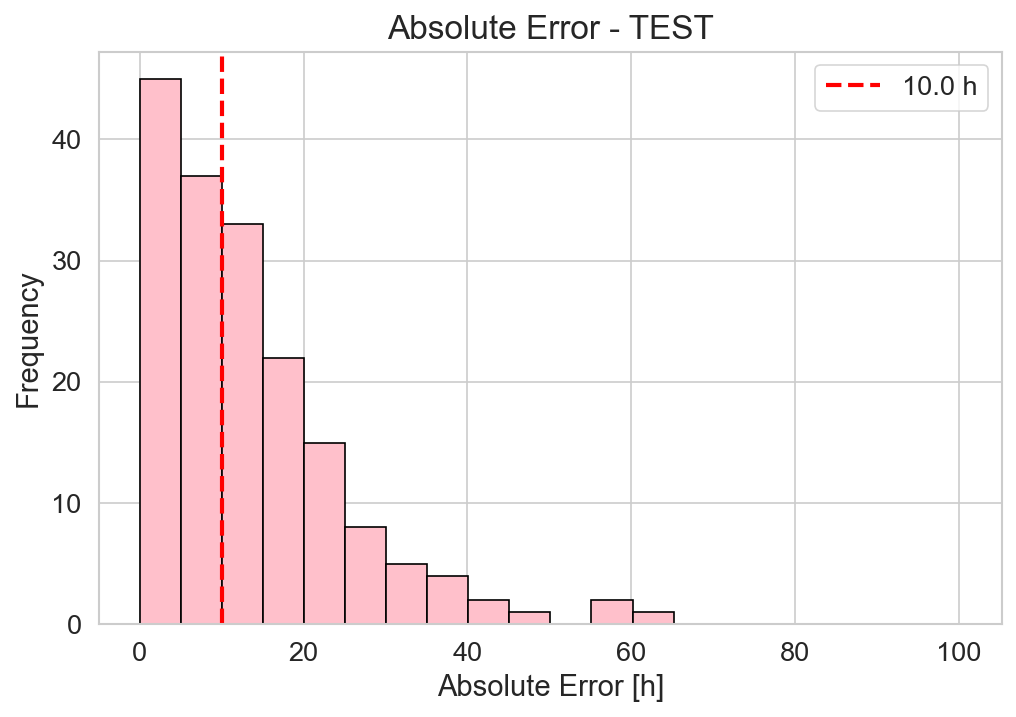

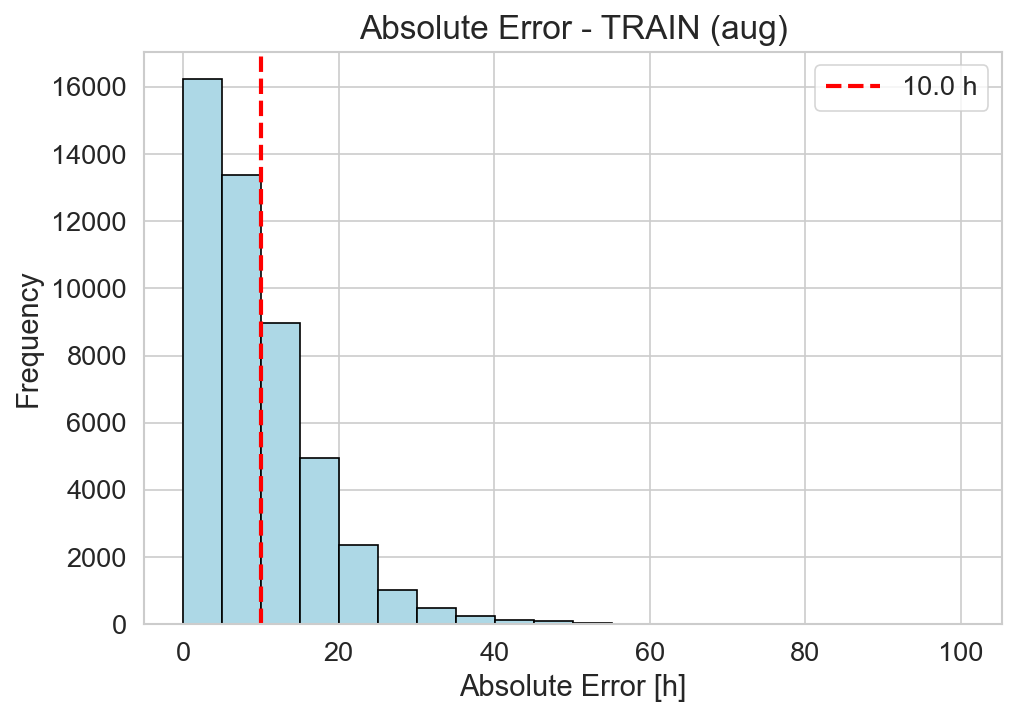

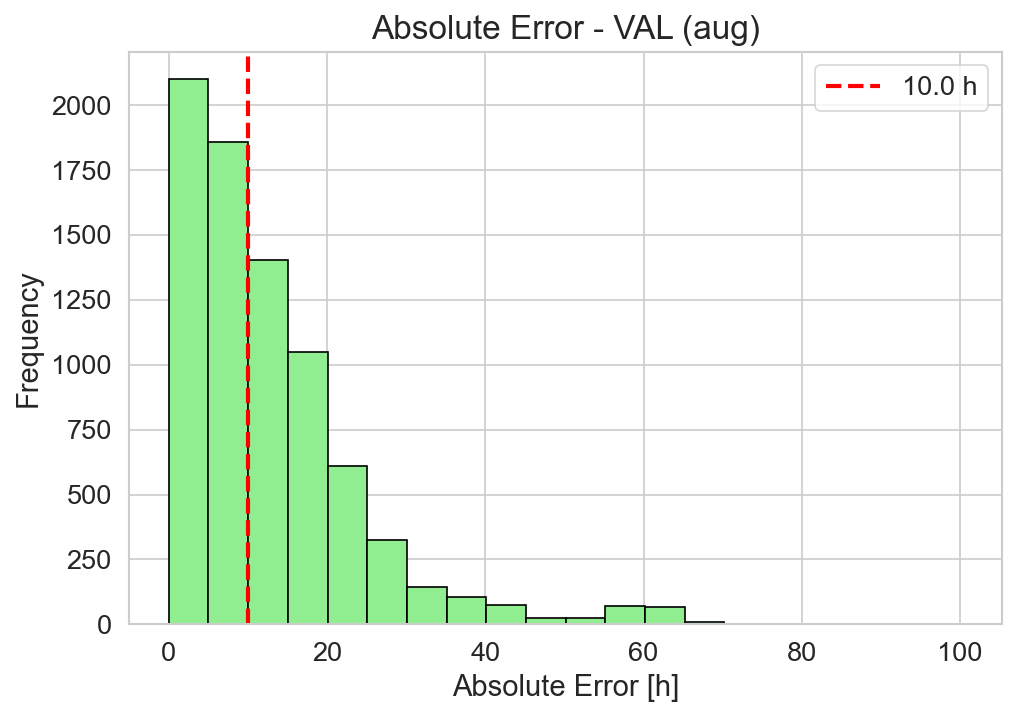

In [7]:
# Uniform bin edges across all splits
all_abs = np.concatenate([
    abs_err_train_real, abs_err_val_real, abs_err_test,
    abs_err_train_aug,  abs_err_val_aug,
])
n_bins = 20
bin_edges = np.linspace(all_abs.min(), all_abs.max(), n_bins + 1)

THRESHOLD = 10.0   # reference threshold at 10 h


def plot_histogram(data, title, color):
    """
    Histogram of absolute errors.
    A dashed red vertical line marks the 10-hour threshold.
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(np.ravel(data), bins=bin_edges, color=color, edgecolor="black")
    ax.axvline(THRESHOLD, color="r", linestyle="--", linewidth=2,
               label=f"{THRESHOLD} h")
    ax.set_xlabel("Absolute Error [h]")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_histogram(abs_err_train_real, "Absolute Error - TRAIN (real)", COLORS["train"])
plot_histogram(abs_err_val_real,   "Absolute Error - VAL (real)",   COLORS["val"])
plot_histogram(abs_err_test,       "Absolute Error - TEST",         COLORS["test"])
plot_histogram(abs_err_train_aug,  "Absolute Error - TRAIN (aug)",  COLORS["train"])
plot_histogram(abs_err_val_aug,    "Absolute Error - VAL (aug)",    COLORS["val"])

## 7. Events below error thresholds

In [8]:
def compute_percentages(data, thresholds):
    """Return percentage of values strictly below each threshold."""
    data  = np.ravel(data)
    total = len(data)
    return [round(100 * np.sum(data < thr) / total, 2) for thr in thresholds]


mean_mae_test = float(mae_test.mean())
thresholds = [10.0, mean_mae_test, 15.0]
thr_labels = [
    "< 10 h",
    f"< {mean_mae_test:.2f} h (mean test MAE)",
    "< 15 h",
]

pct_table = {
    "TRAIN (Real)": compute_percentages(abs_err_train_real, thresholds),
    "VAL (Real)":   compute_percentages(abs_err_val_real,   thresholds),
    "TEST":         compute_percentages(abs_err_test,       thresholds),
    "TRAIN (Aug)":  compute_percentages(abs_err_train_aug,  thresholds),
    "VAL (Aug)":    compute_percentages(abs_err_val_aug,    thresholds),
}

df_pct = pd.DataFrame(pct_table, index=thr_labels)
print("Percentage of events below error thresholds:")
print(df_pct.to_string())

Percentage of events below error thresholds:
                           TRAIN (Real)  VAL (Real)   TEST  TRAIN (Aug)  VAL (Aug)
< 10 h                            73.39        55.0  46.29        61.65      50.06
< 13.34 h (mean test MAE)         86.78        71.0  60.57        75.24      62.82
< 15 h                            91.30        75.0  65.71        80.32      67.97


## 8. Summary statistics table

In [9]:
rows = [
    ("MAE Train (real) [h]",   mae_train_real),
    ("MAE Val (real) [h]",     mae_val_real),
    ("MAE Test [h]",           mae_test),
    ("MedAE Train (real) [h]", medae_train_real),
    ("MedAE Val (real) [h]",   medae_val_real),
    ("MedAE Test [h]",         medae_test),
    ("MAE Train (aug) [h]",    mae_train_aug),
    ("MAE Val (aug) [h]",      mae_val_aug),
]

summary_data = {
    "Metric": [r[0] for r in rows],
    "Mean":   [np.mean(r[1])   for r in rows],
    "Std":    [np.std(r[1])    for r in rows],
    "Min":    [np.min(r[1])    for r in rows],
    "Max":    [np.max(r[1])    for r in rows],
}

df_summary = pd.DataFrame(summary_data).set_index("Metric")
print("Summary statistics across all realizations:")
print(df_summary.round(3).to_string())

Summary statistics across all realizations:
                          Mean    Std    Min     Max
Metric                                              
MAE Train (real) [h]     7.134  2.154  4.102  13.398
MAE Val (real) [h]      11.228  5.547  1.691  23.171
MAE Test [h]            13.342  3.944  6.455  21.523
MedAE Train (real) [h]   5.971  2.419  1.311  11.185
MedAE Val (real) [h]     9.641  4.764  1.705  22.883
MedAE Test [h]          10.691  3.434  4.496  17.497
MAE Train (aug) [h]      9.456  1.459  7.827  13.932
MAE Val (aug) [h]       12.645  4.809  6.685  22.471
